This code uses transferred architecture from the model trained on thorium-oxide molecular clusters and further trained to predict the nuclearity from the calculated PDF data of lanthanide complexes from CSD.

In [1]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, LeakyReLU, Flatten, Dropout
from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope
from keras.callbacks import History, ModelCheckpoint, EarlyStopping
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from keras_tuner import RandomSearch, Hyperband
from keras_tuner.engine.hyperparameters import HyperParameters
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
import keras.regularizers
import keras
import glob
import os
import itertools
import fnmatch

In [2]:
os.chdir('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/all_data/cifs/')

In [7]:
files_calc = glob.glob('*.dat')

In [8]:
raw_data_points = []

with open('labels.txt', 'w') as labels:
    for f in files_calc:
        df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=800, engine='python')
        raw_data_points.append(df.values.ravel())
        if f[0] == 'p':
            labels.write('10')
            labels.write('\n')
        else:    
            labels.write(f[0])
            labels.write('\n')

raw_data_points = np.array(raw_data_points)

# Load the labels
labels = pd.read_csv("labels.txt", header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array

10


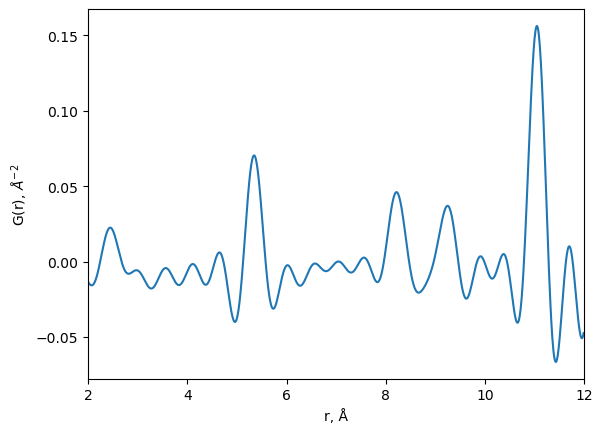

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[77,:]))/100+2, data_points[77,:])
plt.xlabel('r, Å')
plt.ylabel('G(r), $Å^{-2}$')
print(labels[77])

In [13]:
# Let's do some hyperparameter tuning

def build_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Choice('filters1', [8, 16, 32]),
                     kernel_size=hp.Choice('kernel_size1', [64, 128, 256]),
                     activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.9, step=0.1)))
    model.add(Conv1D(filters=hp.Choice('filters2', [32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64]),
                     activation='relu'))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.9, step=0.1)))
    model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
    model.add(Flatten())
    model.add(Dense(units=hp.Choice('dense_units', [64, 128, 256]), activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.9, step=0.1)))
    model.add(Dense(units=11, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))
    optimizer = Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-1, sampling='log'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [14]:
X_train, X_val, y_train, y_val = train_test_split(data_points, labels, test_size=0.2, random_state=42)
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=200,
    factor=3,
    project_name='hyperband_2-12'
)

tuner.search(X_train, y_train, epochs=200, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_loss', patience=3)])
tuner.search_space_summary()
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hyperparameters.values)
best_model = tuner.get_best_models(num_models=1)[0]
best_model.save('tuned_csd_2-12.h5')

Trial 246 Complete [00h 00m 59s]
val_accuracy: 0.8142856955528259

Best val_accuracy So Far: 0.8500000238418579
Total elapsed time: 01h 04m 44s
INFO:tensorflow:Oracle triggered exit


Search space summary
Default search space size: 7
filters1 (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}
kernel_size1 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.9, 'step': 0.1, 'sampling': 'linear'}
filters2 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
kernel_size2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.1, 'step': None, 'sampling': 'log'}
{'filters1': 8, 'kernel_size1': 128, 'dropout': 0.30000000000000004, 'filters2': 64, 'kernel_size2': 64, 'dense_units': 64, 'learning_rate': 0.00023499675055028255, 'tuner/epochs': 67, 'tuner/initial_epoch': 23, 'tune

In [27]:
def create_model():
    # Tuning of the model

    model = Sequential()
    # Add the convolutional layers
    model.add(Conv1D(filters=8, kernel_size=128, activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    model.add(Conv1D(filters=64, kernel_size=64, activation='relu'))
    model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL)) 

    # Flatten the output of the convolutional layers
    model.add(Flatten())

    # Add the fully connected layers
    model.add(Dense(units=64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))) # 128 
    model.add(Dropout(0.3))
    model.add(Dense(units=11, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01))) # 10 

    # Compile the model
    optimizer = Adam(learning_rate=0.00023)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [28]:
num_folds = 10
num_epochs = 200
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
fold_num = 1 
all_fold_results = []
histories = []

In [29]:
for train_index, val_index in kf.split(data_points):
    X_train, X_val = data_points[train_index], data_points[val_index]
    y_train, y_val = labels[train_index], labels[val_index]
    
    model = create_model()
    
    checkpoint_name = f"workflow_fold_{fold_num}_model.hdf5"
    checkpoint = ModelCheckpoint(checkpoint_name, monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
    
    print(f'Training fold {fold_num}...')
    history = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint])
    histories.append(history)

    # Load the best model saved by the checkpoint and evaluate
    with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
        load_model = keras.models.load_model(checkpoint_name)
        
    val_loss, val_acc = load_model.evaluate(X_val, y_val)
    print(f'Fold {fold_num} accuracy:', val_acc)
    
    all_fold_results.append(val_acc)
    
    fold_num += 1

# Print overall performance across all folds
print('All fold accuracies:', all_fold_results)
print('Mean accuracy:', np.mean(all_fold_results))
print('Standard deviation:', np.std(all_fold_results))

Training fold 1...
Epoch 1/200
20/20 [==============================] - ETA: 0s - loss: 2.8494 - accuracy: 0.5365
Epoch 1: val_accuracy improved from -inf to 0.34286, saving model to workflow_fold_1_model.hdf5
20/20 [==============================] - 2s 86ms/step - loss: 2.8494 - accuracy: 0.5365 - val_loss: 3.5006 - val_accuracy: 0.3429
Epoch 2/200
20/20 [==============================] - ETA: 0s - loss: 2.1546 - accuracy: 0.6746
Epoch 2: val_accuracy improved from 0.34286 to 0.37143, saving model to workflow_fold_1_model.hdf5
20/20 [==============================] - 2s 77ms/step - loss: 2.1546 - accuracy: 0.6746 - val_loss: 3.2681 - val_accuracy: 0.3714
Epoch 3/200
20/20 [==============================] - ETA: 0s - loss: 1.8512 - accuracy: 0.7333
Epoch 3: val_accuracy did not improve from 0.37143
20/20 [==============================] - 1s 74ms/step - loss: 1.8512 - accuracy: 0.7333 - val_loss: 3.1108 - val_accuracy: 0.3429
Epoch 4/200
20/20 [==============================] - ETA: 0s

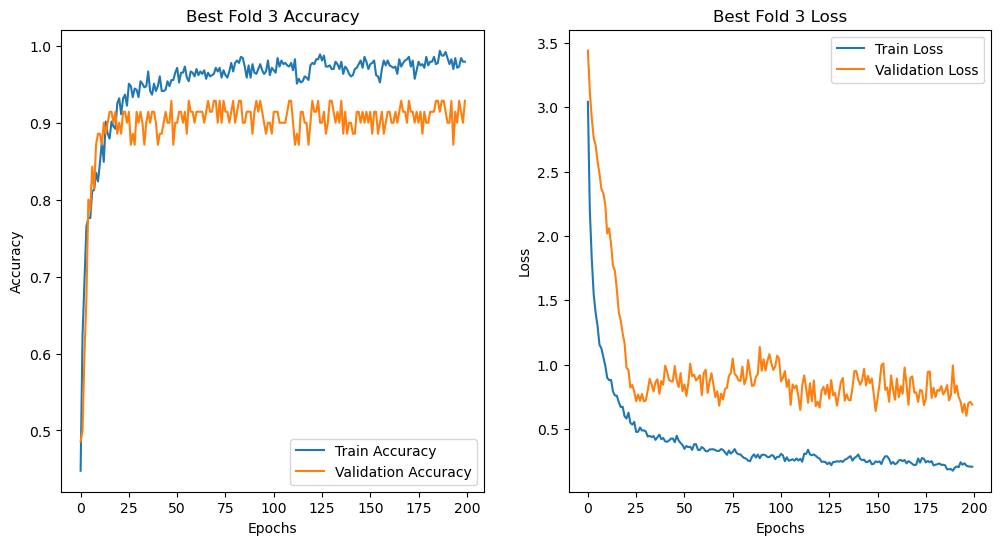

In [30]:
# Identifying the best fold (assuming higher validation accuracy is better)
best_fold_index = np.argmax([np.max(hist.history['val_accuracy']) for hist in histories])

# Plotting metrics for the best fold
best_history = histories[best_fold_index]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'], label='Train Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f'Best Fold {best_fold_index + 1} Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title(f'Best Fold {best_fold_index + 1} Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


5/5 [==============================] - 0s 24ms/step
Recall score: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
F1 score: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Precision score: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Confusion matrix, without normalization
[[19  0  0  0  0  0  0  0  0  0]
 [ 0 26  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0 19  0  0  0  0  0  0]
 [ 0  0  0  0  2  0  0  0  0  0]
 [ 0  0  0  0  0 11  0  0  0  0]
 [ 0  0  0  0  0  0  5  0  0  0]
 [ 0  0  0  0  0  0  0  6  0  0]
 [ 0  0  0  0  0  0  0  0  5  0]
 [ 0  0  0  0  0  0  0  0  0 46]]


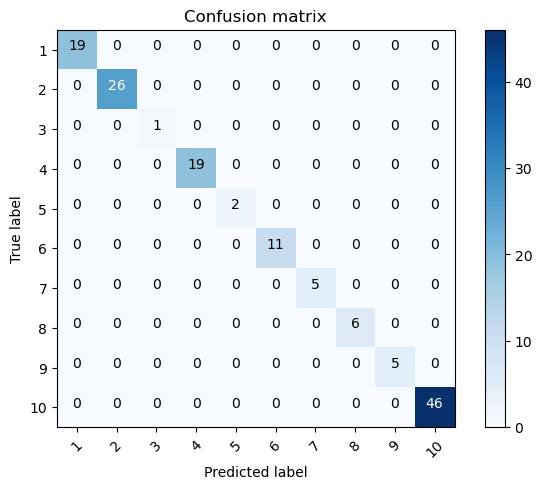

In [38]:
X_train, X_val, y_train, y_val = train_test_split(data_points, labels, test_size=0.2, random_state=42)

with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/all_data/cifs/new_fold_3_model.hdf5')

load_model.evaluate(X_val, y_val)
y_pred_prob = load_model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_val, y_pred)
recall = recall_score(y_val, y_pred, average=None)
f1 = f1_score(y_val, y_pred, average=None)
precision = precision_score(y_val, y_pred, average=None)
#print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_val), title='Confusion matrix', normalize=False)
plt.show()

In [39]:
# Extraction of attention weights from the model
from keras.models import Model

with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    loaded_model = keras.models.load_model('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/all_data/cifs/new_fold_3_model.hdf5')
attention_layer = [layer for layer in loaded_model.layers if 'SeqSelfAttention' in str(layer)][0]
model_with_attentions = Model(inputs=loaded_model.input, 
                              outputs=[loaded_model.output, attention_layer.output])

total_samples = X_val.shape[0]
batch_size = 32 # keras default
all_attention_weights = []
for i in range(0, total_samples, batch_size):
    batch_input = X_val[i:i+batch_size]
    _, attention_weights = model_with_attentions.predict(batch_input, verbose='none')
    all_attention_weights.append(attention_weights)
all_attention_weights = np.concatenate(all_attention_weights, axis=0)
average_attention_weights = np.mean(all_attention_weights, axis=0)
summed_attention_weights = np.sum(average_attention_weights, axis=0)

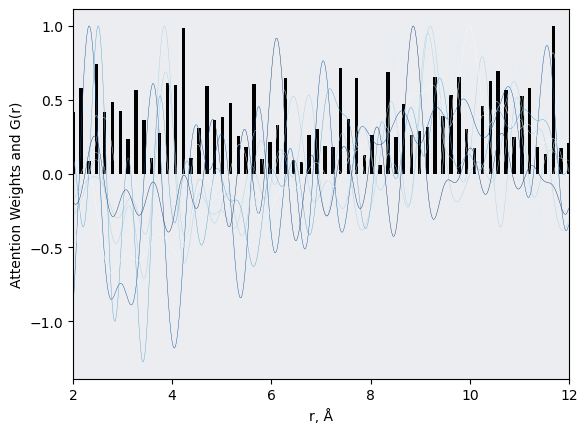

In [52]:
# Plotting of attention weights together with the first 300 PDFs of the dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import get_cmap

min_val = np.min(labels)
max_val = np.max(labels)
normalized_labels = (labels - min_val) / (max_val - min_val)
colormap = get_cmap('Blues')


fig, ax = plt.subplots()
for i in range(1,10):
    color = colormap(normalized_labels[i])
    plt.plot(np.arange(len(data_points[i,:]))/100+2, data_points[i,:]/data_points[i,:].max(), 
             alpha=1, linewidth=0.3, color=color)
ax.bar(np.linspace(2, 12, 64), summed_attention_weights/summed_attention_weights.max(), width=0.07, color='black')
ax.set_facecolor('#ebedf0')
plt.xlabel('r, Å')
plt.ylabel('Attention Weights and G(r)')
ax.set_xlim(2,12)
plt.show()

10


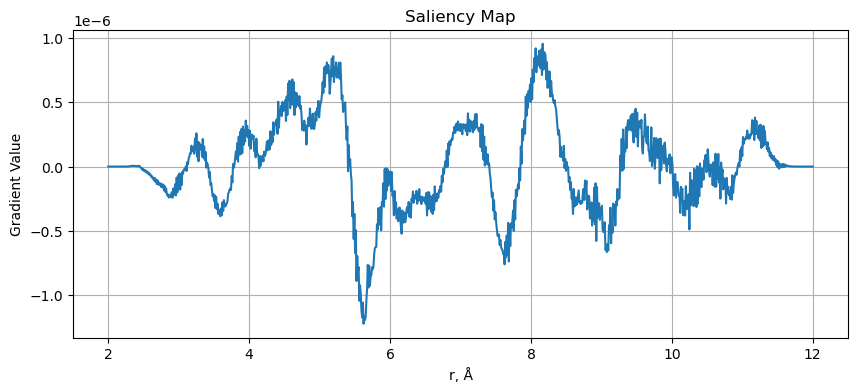

In [55]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load pre-trained model
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    model = keras.models.load_model('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/all_data/cifs/new_fold_3_model.hdf5')

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

sample_index = 5  
sample_label = y_train[sample_index]
some_input = tf.convert_to_tensor(X_train[sample_index].reshape(1, 1000, 1), dtype=tf.float32)  # Adjust shape according to your input

with tf.GradientTape() as tape:
    tape.watch(some_input)
    prediction = model(some_input)
    loss = prediction[0][sample_label]

grad_values = tape.gradient(loss, some_input)
grad_numpy = grad_values.numpy().reshape(1000)
print(y_train[sample_index])
angstrom_range = 2 + np.linspace(0, 1000, 1000) / 100

# Plot
plt.figure(figsize=(10, 4))
plt.plot(angstrom_range, grad_numpy)
plt.title('Saliency Map')
plt.xlabel('r, Å')
plt.ylabel('Gradient Value')
plt.grid(True)
plt.show()

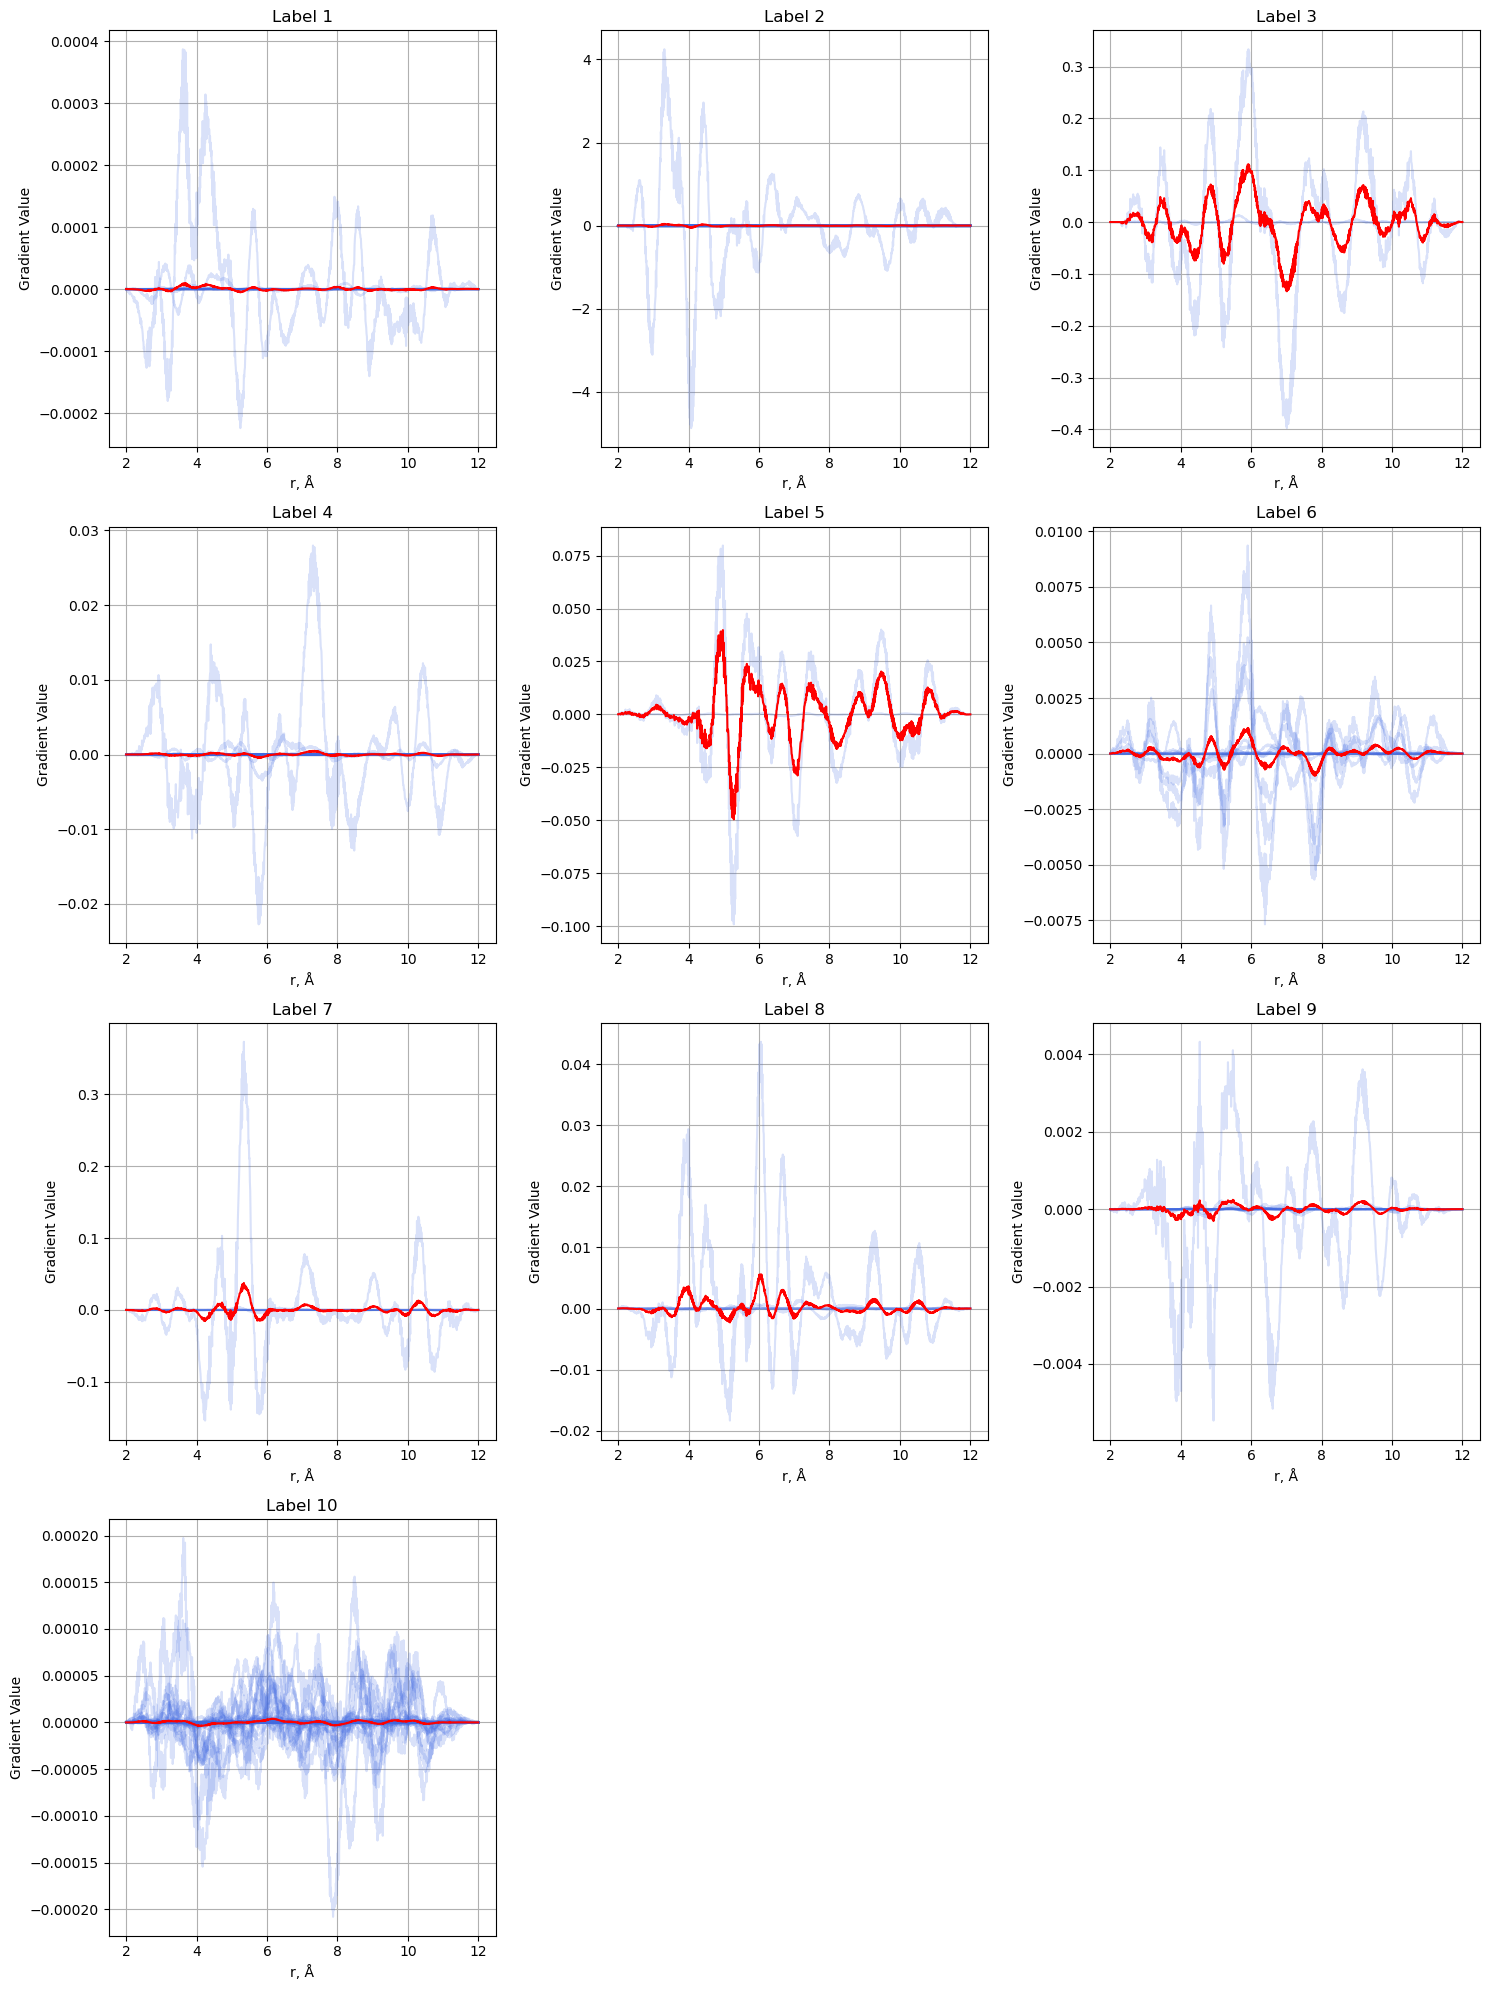

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

sample_size = 400
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

# Loop through the unique labels (from 1 to 10)
for label in range(1, 11):
    ax = axes[(label - 1) // 3, (label - 1) % 3]
    gradients = []
    
    # Loop through first `sample_size` samples to check for this label
    for idx in range(min(sample_size, len(y_train))):
        if y_train[idx] == label:
            sample_input = tf.convert_to_tensor(X_train[idx].reshape(1, 1000, 1), dtype=tf.float32)
            
            with tf.GradientTape() as tape:
                tape.watch(sample_input)
                prediction = model(sample_input)
                loss = prediction[0][label - 1]  # Adjust for 0-based index
            
            grad_values = tape.gradient(loss, sample_input)
            grad_numpy = grad_values.numpy().reshape(1000)
            gradients.append(grad_numpy)
            
            angstrom_range = 2 + np.linspace(0, 1000, 1000) / 100
            ax.plot(angstrom_range, grad_numpy, alpha=0.2, color='royalblue')
    
    # Plot the average line if we have any gradients for this label
    if gradients:
        mean_gradient = np.mean(gradients, axis=0)
        ax.plot(angstrom_range, mean_gradient, color='red')
    
    ax.set_title(f'Label {label}')
    ax.set_xlabel('r, Å')
    ax.set_ylabel('Gradient Value')
    ax.grid(True)

fig.delaxes(axes[3,1])
fig.delaxes(axes[3,2])

plt.tight_layout()
plt.savefig('saliency_maps.png', dpi=400)
plt.show()